# No PCA

## Import + data loading 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')
from matplotlib.patches import Patch
sns.set_style("whitegrid")

#Filtering 
filter=True

#Conservative specification
emilio=False

# LOAD DATA
GITHUB_BASE = "https://raw.githubusercontent.com/AyaanTigdikar/Capstone/main/MASTER/"
master = pd.read_csv(f"{GITHUB_BASE}Master.csv").drop(columns=['Unnamed: 0'], errors='ignore')
print(f"Master: {len(master)} obs, {master['Country Code'].nunique()} countries")

# PREPARE PANEL
df = master[(master['Year'] >= 1995) & (master['Year'] <= 2019)].dropna(subset=['Economic Complexity Index']).copy()
df = df.sort_values(['Country Code', 'Year'])
resource_rich_countries = master[master['Year'] == 1995][
    master[master['Year'] == 1995]['Total natural resources rents (% of GDP)'] >= 5
]['Country Code'].unique()
if filter:
    df = df[df['Country Code'].isin(resource_rich_countries)]
df['Resource_Rich'] = df['Country Code'].isin(resource_rich_countries).astype(int)

Master: 3150 obs, 126 countries


In [2]:
# ============================================================
# GRAPH STYLE (from 0_graph_style.ipynb) – matplotlib/seaborn
# ============================================================
import matplotlib as mpl

STYLE = {
    'font_family': 'IBM Plex Sans',           # falls back to DejaVu Sans if not installed
    'tick_size': 11,
    'axis_title_size': 13,
    'legend_size': 11,
    'annotation_size': 10,
    'title_color': '#1a2744',
    'plot_bg': '#fafafa',
    'paper_bg': '#fafafa',
    'grid_color': '#e5e7eb',
    'grid_width': 0.5,
    'zero_line_color': '#c9cfd6',
    # Bold palette colours – match plotly notebooks
    'colors': {
        'purple':   '#7F3C8D',   # Some Oil, No Minerals
        'teal':     '#11A579',   # Oil, Few Minerals
        'blue':     '#3969AC',   # No Oil, No Minerals
        'yellow':   '#F2B701',   # Minerals, No Oil
        'red':      '#E73F74',   # negative / highlight
        'orange':   '#E68310',   # interactions
        'green':    '#11A579',   # positive
    },
}

# Positive / negative bar colours (replaces #2ECC71 / #E74C3C)
POS_COLOR  = STYLE['colors']['teal']
NEG_COLOR  = STYLE['colors']['red']

# Per-model palette (replaces ad-hoc hex codes)
MODEL_COLORS = {
    'LASSO':         STYLE['colors']['red'],
    'Ridge':         STYLE['colors']['blue'],
    'Elastic Net':   STYLE['colors']['teal'],
    'Random Forest': STYLE['colors']['yellow'],
}

# Feature-type colour map (replaces ad-hoc hex codes in viz 1)
FEAT_COLORS = {
    'pca':          STYLE['colors']['purple'],
    'interaction':  STYLE['colors']['orange'],
    'resource':     STYLE['colors']['red'],
    'base':         STYLE['colors']['blue'],
}

# Apply global rcParams
mpl.rcParams.update({
    'font.family':          'sans-serif',
    'font.sans-serif':      [STYLE['font_family'], 'DejaVu Sans'],
    'font.size':            STYLE['tick_size'],
    'axes.titlesize':       STYLE['axis_title_size'],
    'axes.labelsize':       STYLE['axis_title_size'],
    'axes.titlecolor':      STYLE['title_color'],
    'axes.labelcolor':      STYLE['title_color'],
    'axes.facecolor':       STYLE['plot_bg'],
    'figure.facecolor':     STYLE['paper_bg'],
    'axes.edgecolor':       STYLE['grid_color'],
    'axes.grid':            True,
    'grid.color':           STYLE['grid_color'],
    'grid.linewidth':       STYLE['grid_width'],
    'grid.alpha':           0.7,
    'xtick.color':          STYLE['title_color'],
    'ytick.color':          STYLE['title_color'],
    'xtick.labelsize':      STYLE['tick_size'],
    'ytick.labelsize':      STYLE['tick_size'],
    'legend.fontsize':      STYLE['legend_size'],
    'legend.framealpha':    0.95,
    'legend.edgecolor':     STYLE['grid_color'],
    'savefig.facecolor':    STYLE['paper_bg'],
    'savefig.dpi':          300,
})
print("Style applied.")


Style applied.


## Model

In [3]:
# Interactions
df['HCI_x_ProductionValue'] = df['Human capital index'] * df['Total_Production_Value']
df['RuleOfLaw_x_ProductionValue'] = df['Rule of law index'] * df['Total_Production_Value']
df['GFCF_x_ProductionValue']=df['Gross fixed capital formation, all, Constant prices, Percent of GDP']* df['Total_Production_Value']

if emilio:
    base_features = [
        'Human capital index', 'Rule of law index', 'Political stability — estimate',
        'Trade (% of GDP)', 'Gross fixed capital formation, all, Constant prices, Percent of GDP', 
        'Total_Production_Value'
    ]

else:
    base_features = [
        'Human capital index', 'Rule of law index', 'Political stability — estimate',
        'Trade (% of GDP)', 'Gross fixed capital formation, all, Constant prices, Percent of GDP',
        'Share of investment in GDP',
        'Domestic credit to private sector (% of GDP)', 'Landlocked',
        'Urban population (% of total population)', 'Government revenue',
        'Capital depreciation rate', 'Use of IMF credit (DOD, current US$)', 'Services',
        'Real interest rate (%)', 'Inflation, consumer prices (annual %)',
        'Access to electricity (% of population)', 'Adjusted savings: gross savings (% of GNI)', 
        'Total_Production_Value'
    ]

if filter:
    all_features = base_features +  ['HCI_x_ProductionValue', 'RuleOfLaw_x_ProductionValue','GFCF_x_ProductionValue']
else:
    all_features = base_features + ['Resource_Rich','HCI_x_ProductionValue', 'RuleOfLaw_x_ProductionValue',"GFCF_x_ProductionValue"]

print(f"Total features: {len(all_features)} (17 base + 1 group + 2 interactions)")

y = df['Economic Complexity Index'].values
X = df[all_features].copy()
years = df['Year'].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.values)

# Split
train_mask = years <= 2014
X_train, X_test = X_scaled[train_mask], X_scaled[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

# Train
tscv = TimeSeriesSplit(n_splits=5)
lasso = LassoCV(cv=tscv, random_state=42, max_iter=10000).fit(X_train, y_train)
ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=tscv).fit(X_train, y_train)
elastic = ElasticNetCV(cv=tscv, random_state=42, max_iter=10000).fit(X_train, y_train)
rf = RandomForestRegressor(n_estimators=200, max_depth=4, min_samples_leaf=10, 
                           random_state=42, n_jobs=-1, oob_score=True).fit(X_train, y_train)

models = {'LASSO': lasso, 'Ridge': ridge, 'Elastic Net': elastic, 'Random Forest': rf}

print("All models trained")

# Collect importance
all_importance = pd.DataFrame({'Feature': all_features})
feature_signs = pd.DataFrame({'Feature': all_features})
for name, model in models.items():
    if name in ['LASSO', 'Ridge', 'Elastic Net']:
        all_importance[name] = np.abs(model.coef_)
        feature_signs[name] = np.sign(model.coef_)
    else:
        all_importance[name] = model.feature_importances_
        feature_signs[name] = 1.0
all_importance['Average'] = all_importance[['LASSO', 'Ridge', 'Elastic Net', 'Random Forest']].mean(axis=1)

# Performance
perf = []
for name, model in models.items():
    perf.append({
        'Model': name,
        'Test_R2': model.score(X_test, y_test),
        'Train_R2': model.score(X_train, y_train)
    })
perf_df = pd.DataFrame(perf).sort_values('Test_R2', ascending=False)

print("Importance collected from all models")

Total features: 21 (17 base + 1 group + 2 interactions)
All models trained
Importance collected from all models


## Graphics

Plot exported successfully as barplot_ml_high_res.png


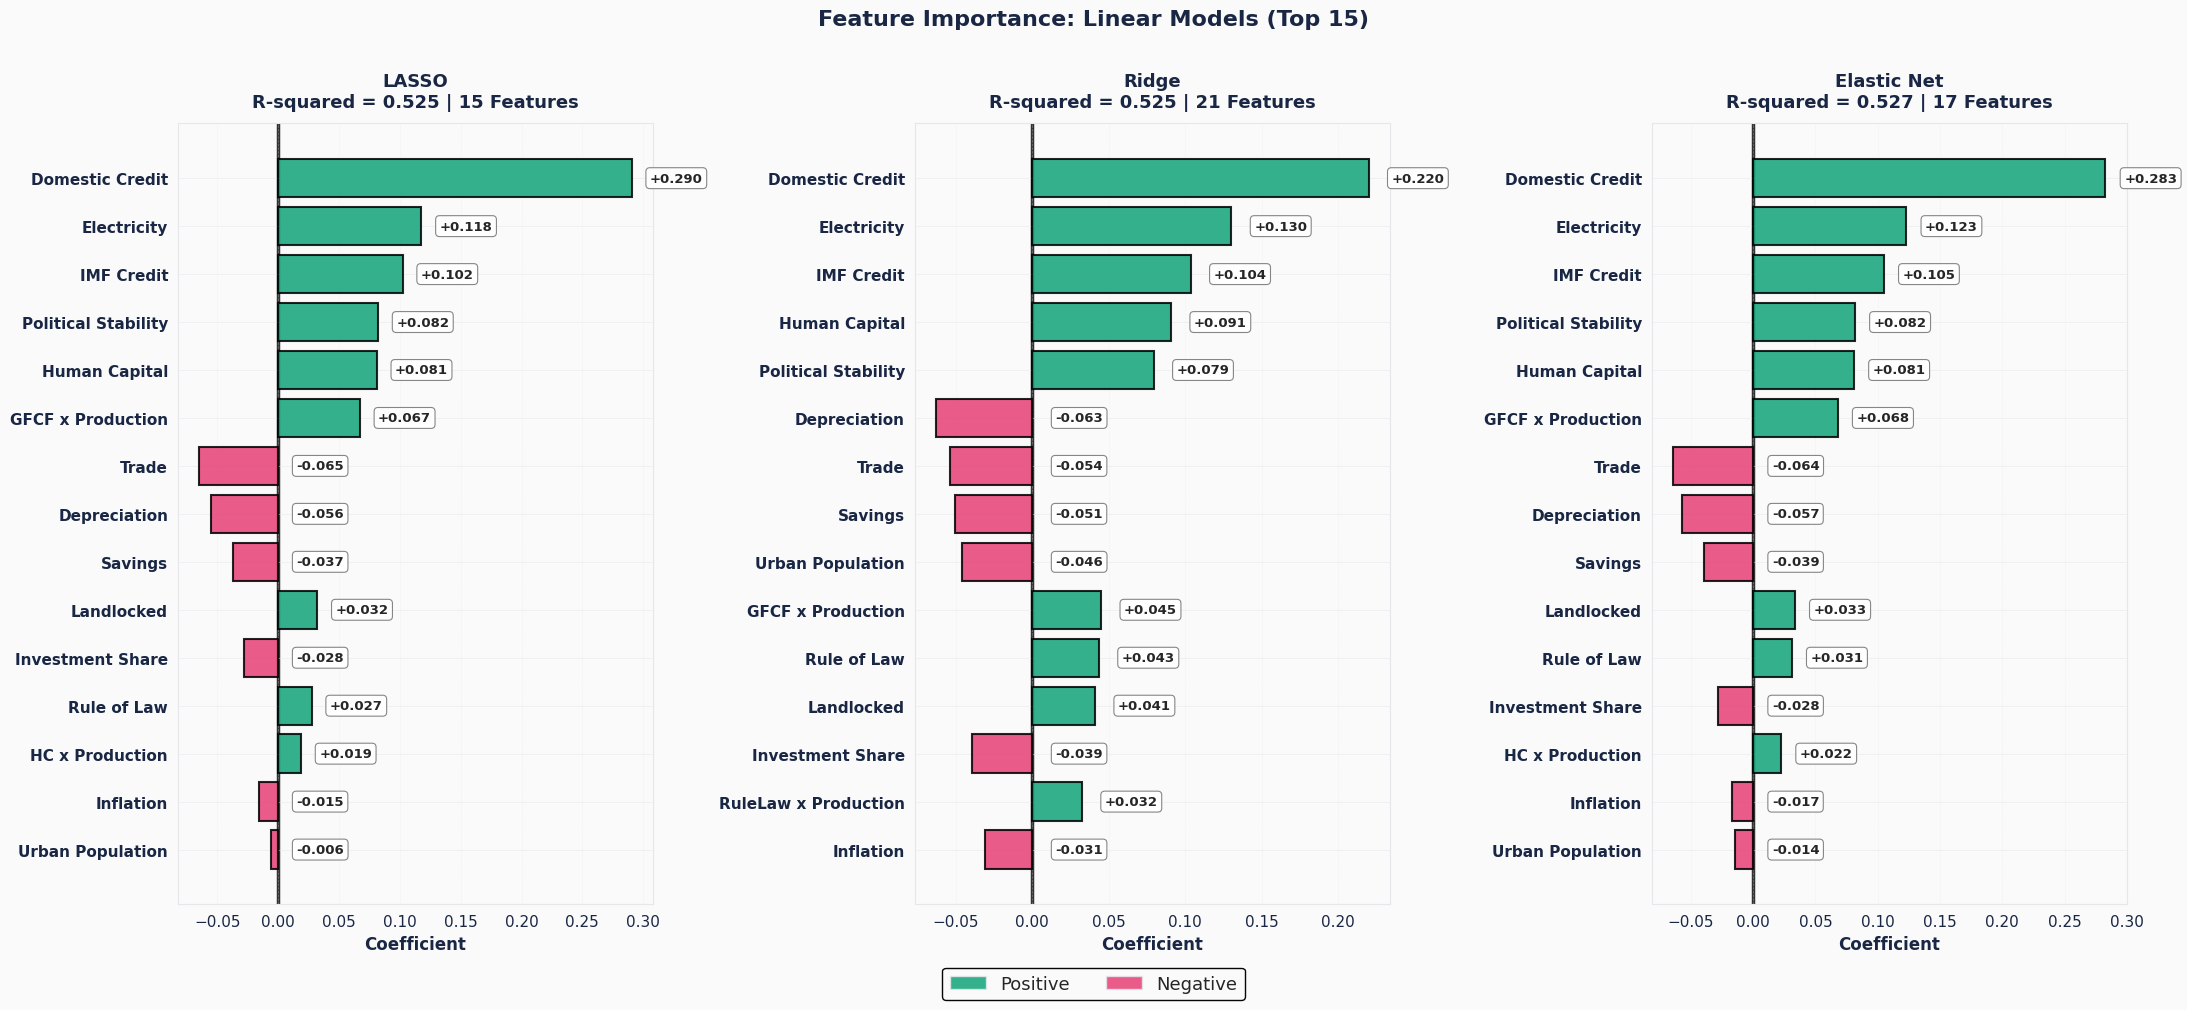

Plot exported successfully as heatmap_ml_high_res.png
Plot exported successfully as histograms_ml_high_res.png
Plot exported successfully as symbols_ml.png


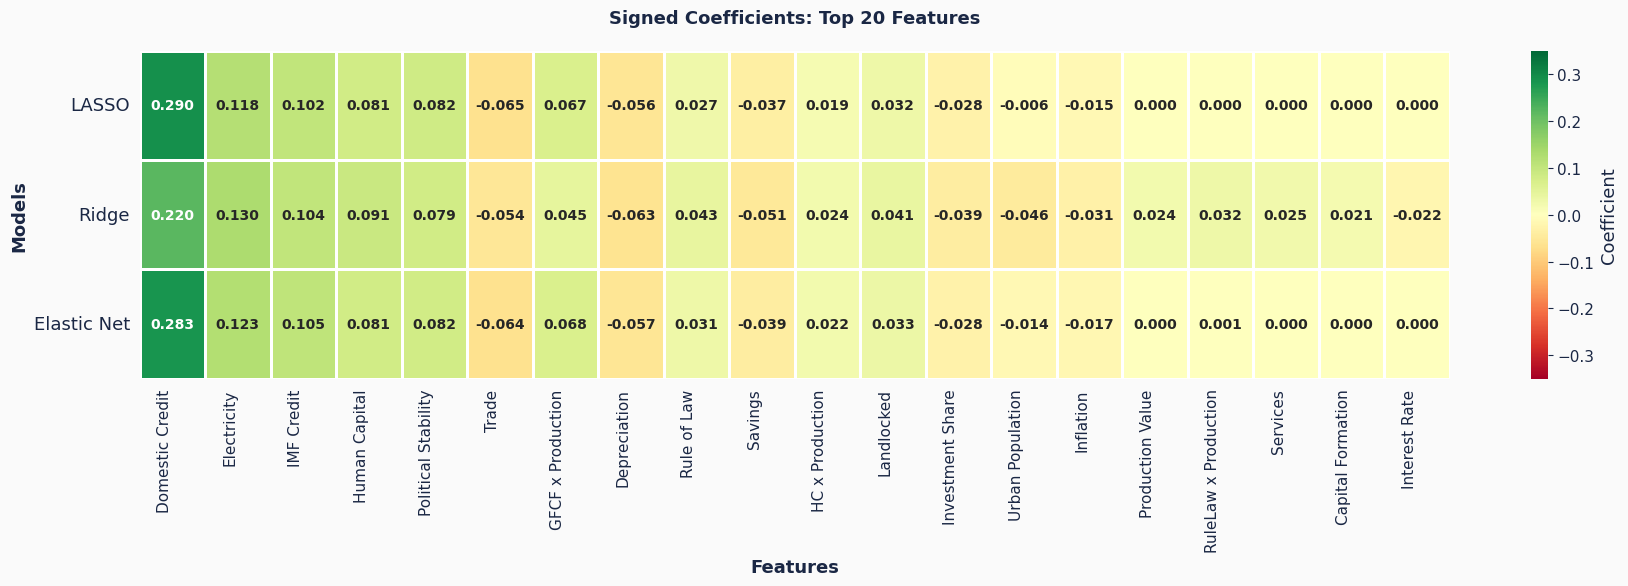

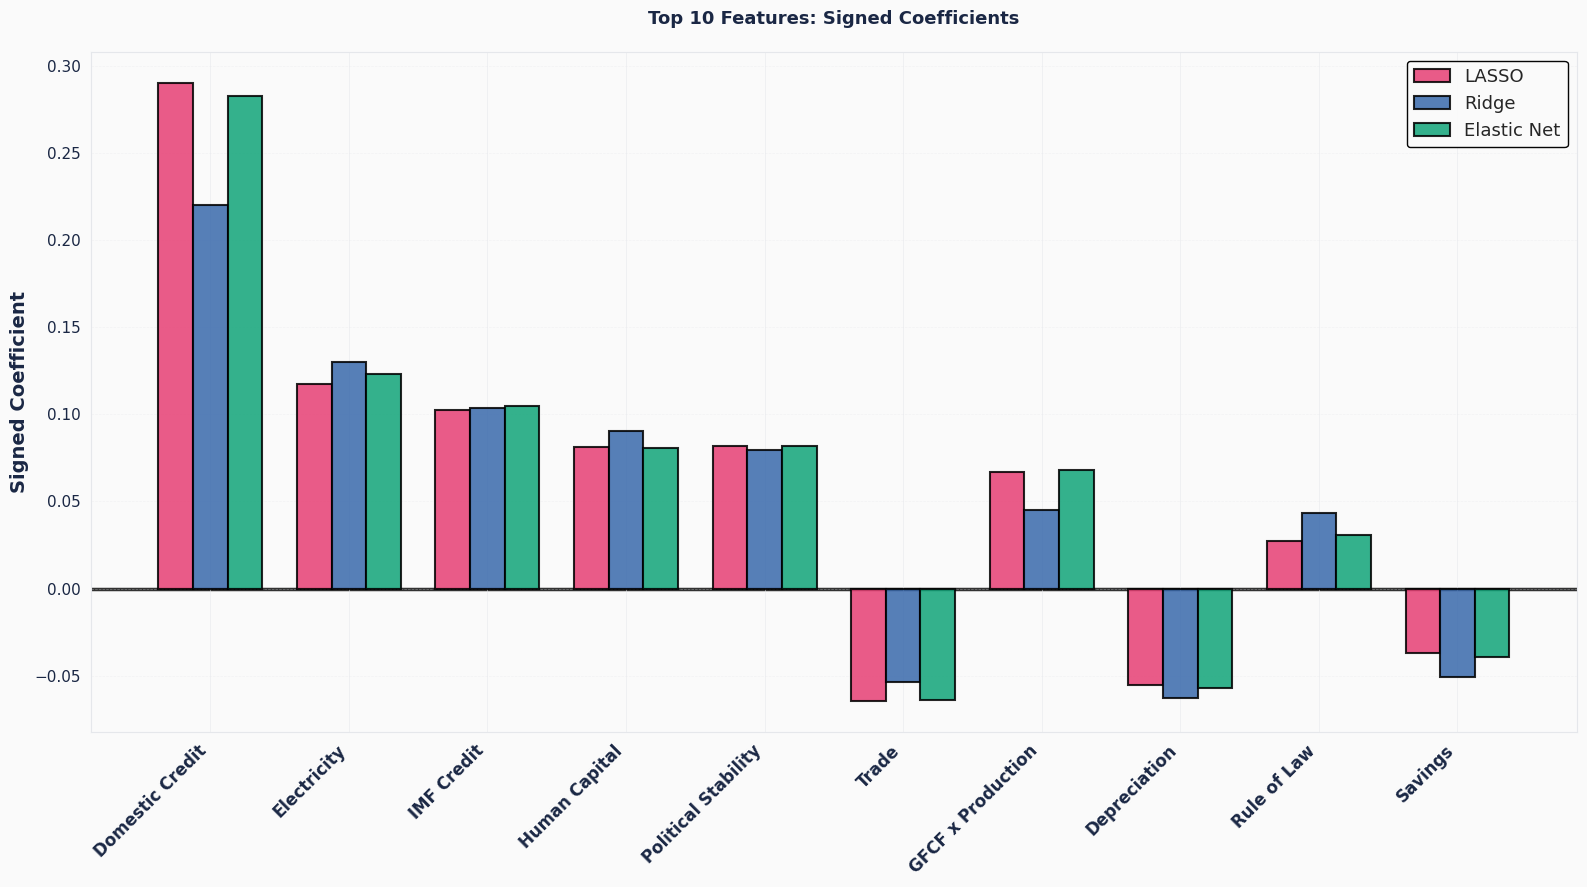

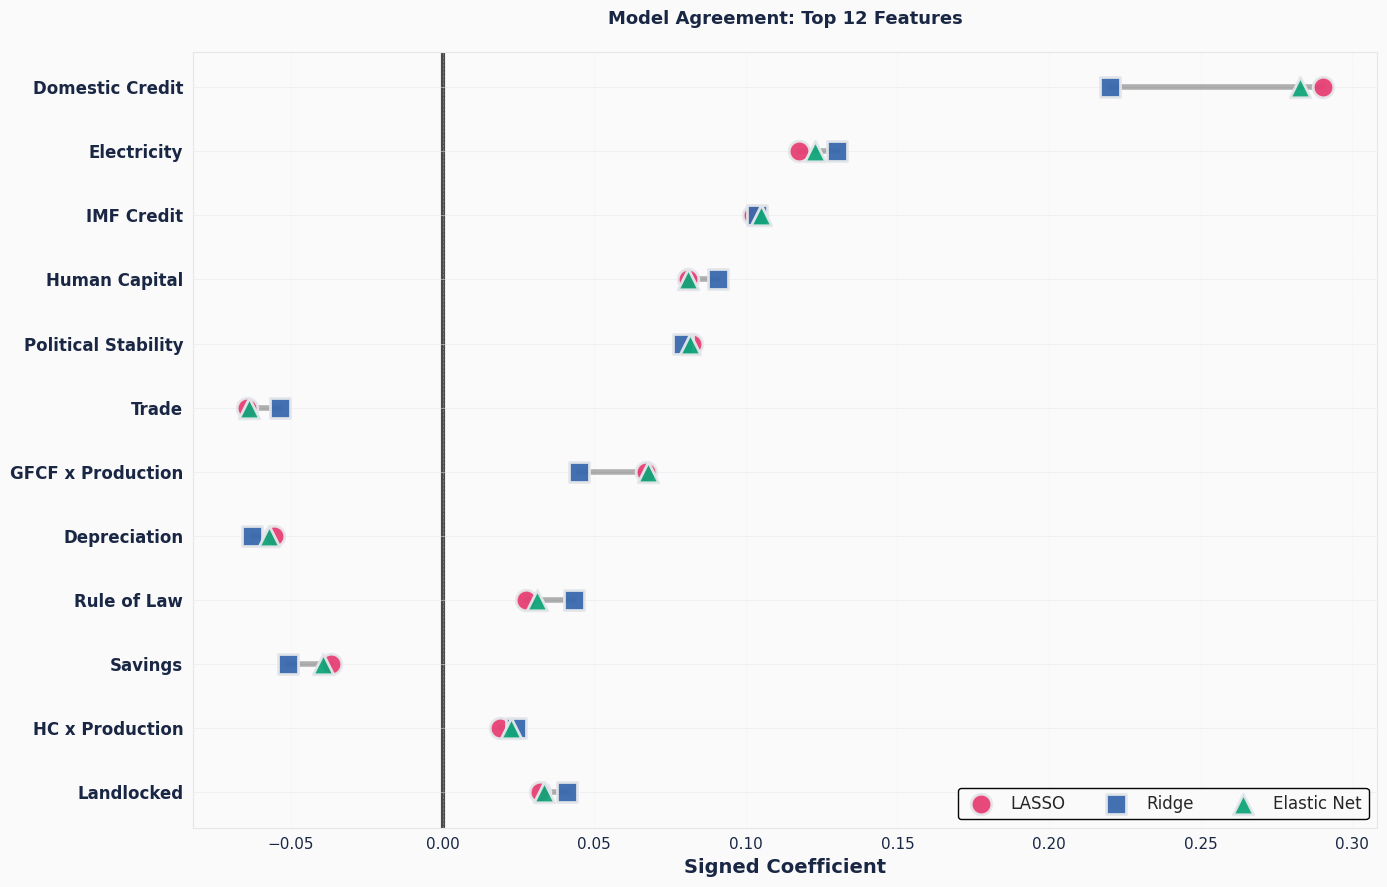

In [4]:
# Name mapping for shorter labels
name_mapping = {
    'Human capital index': 'Human Capital',
    'Rule of law index': 'Rule of Law',
    'Political stability — estimate': 'Political Stability',
    'Trade (% of GDP)': 'Trade',
    'Gross fixed capital formation, all, Constant prices, Percent of GDP': 'Capital Formation',
    'Share of investment in GDP': 'Investment Share',
    'Domestic credit to private sector (% of GDP)': 'Domestic Credit',
    'Landlocked': 'Landlocked',
    'Urban population (% of total population)': 'Urban Population',
    'Government revenue': 'Gov Revenue',
    'Capital depreciation rate': 'Depreciation',
    'Use of IMF credit (DOD, current US$)': 'IMF Credit',
    'Services': 'Services',
    'Real interest rate (%)': 'Interest Rate',
    'Inflation, consumer prices (annual %)': 'Inflation',
    'Access to electricity (% of population)': 'Electricity',
    'Adjusted savings: gross savings (% of GNI)': 'Savings',
    'Total_Production_Value': 'Production Value',
    'Resource_Rich': 'Resource Rich',
    'HCI_x_ProductionValue': 'HC x Production',
    'RuleOfLaw_x_ProductionValue': 'RuleLaw x Production',
    'GFCF_x_ProductionValue': 'GFCF x Production'
}

def shorten_name(name):
    return name_mapping.get(name, name[:22])

# ============================================================================
# VISUALIZATION 1: 3-Panel Comparison (LASSO, Ridge, Elastic Net)
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(22, 10))

for idx, model_name in enumerate(['LASSO', 'Ridge', 'Elastic Net']):
    ax = axes[idx]
    
    # Get top 15 with signs
    signed_vals = models[model_name].coef_
    abs_vals = np.abs(signed_vals)
    top_15_idx = np.argsort(abs_vals)[::-1][:15]
    
    top_15_features = [all_features[i] for i in top_15_idx]
    top_15_values = signed_vals[top_15_idx]
    
    # Color by sign
    colors = [POS_COLOR if v > 0 else NEG_COLOR for v in top_15_values]
    labels = [shorten_name(f) for f in top_15_features]
    
    y_pos = np.arange(len(top_15_features))
    bars = ax.barh(y_pos, top_15_values, color=colors, alpha=0.85, 
                  edgecolor='black', linewidth=1.5)
    
    ax.axvline(0, color='black', linewidth=2.5, alpha=0.8, zorder=0)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=11, fontweight='bold')
    ax.set_xlabel('Coefficient', fontsize=12, fontweight='bold')
    
    test_r2 = perf_df[perf_df['Model'] == model_name]['Test_R2'].values[0]
    n_features = np.sum(abs_vals != 0)
    ax.set_title(f'{model_name}\nR-squared = {test_r2:.3f} | {n_features} Features', 
                fontsize=STYLE['axis_title_size'], fontweight='bold', color=STYLE['title_color'], pad=12)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.4, linestyle='--', color=STYLE['grid_color'])
    
    # Add values
    for i, val in enumerate(top_15_values):
        if abs(val) > 0.005:
            if val > 0:
                # Positive: show from right of bar
                x_offset = abs(val) + 0.015
            else:
                # Negative: show at zero line
                x_offset = 0.015
            
            ha = 'left'  # Always left-align
            ax.text(x_offset, i, f'{val:+.3f}', 
                va='center', ha=ha, fontsize=9.5, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                            alpha=0.95, edgecolor='gray', linewidth=0.8))

fig.legend(handles=[
    Patch(facecolor=POS_COLOR, label='Positive', alpha=0.85, edgecolor=STYLE['grid_color'], linewidth=1),
    Patch(facecolor=NEG_COLOR, label='Negative', alpha=0.85, edgecolor=STYLE['grid_color'], linewidth=1)
], loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=2, fontsize=13, 
   framealpha=0.98, edgecolor='black', fancybox=True)

plt.suptitle('Feature Importance: Linear Models (Top 15)', 
             fontsize=16, fontweight='bold', color=STYLE['title_color'], y=0.98)
plt.tight_layout(rect=[0, 0.02, 1, 0.97])

# Increase resolution and export
output_filename = 'barplot_ml_high_res.png'
# dpi=300 is standard for print; dpi=600 is ultra-high res
plt.savefig(f"..\\figures\\ml\\{output_filename}", dpi=300, bbox_inches='tight', facecolor='white')
print(f"Plot exported successfully as {output_filename}")
plt.show()

# ============================================================================
# VISUALIZATION 2: Signed Heatmap
# ============================================================================

fig, ax = plt.subplots(figsize=(18, 6))

top_20 = all_importance.sort_values('Average', ascending=False).head(20)

signed_matrix = pd.DataFrame(index=['LASSO', 'Ridge', 'Elastic Net'])

for feat in top_20['Feature']:
    feat_match = feature_signs[feature_signs['Feature'] == feat]
    if len(feat_match) == 0:
        continue
    
    feat_signs = feat_match.iloc[0]
    feat_importance = all_importance[all_importance['Feature'] == feat].iloc[0]
    
    for model in ['LASSO', 'Ridge', 'Elastic Net']:
        signed_matrix.loc[model, shorten_name(feat)] = feat_signs[model] * feat_importance[model]

signed_matrix = signed_matrix.astype(float)

sns.heatmap(signed_matrix, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
           cbar_kws={'label': 'Coefficient'}, 
           linewidths=2, linecolor='white', ax=ax, 
           vmin=-0.35, vmax=0.35, annot_kws={'fontsize': 10, 'fontweight': 'bold'})

ax.set_title('Signed Coefficients: Top 20 Features', 
            fontsize=STYLE['axis_title_size'], fontweight='bold', color=STYLE['title_color'], pad=20)
ax.set_xlabel('Features', fontsize=13, fontweight='bold')
ax.set_ylabel('Models', fontsize=13, fontweight='bold')

plt.xticks(rotation=90, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=13)
plt.tight_layout()
output_filename = 'heatmap_ml_high_res.png'
# dpi=300 is standard for print; dpi=600 is ultra-high res
plt.savefig(f"..\\figures\\ml\\{output_filename}", dpi=300, bbox_inches='tight', facecolor='white')
print(f"Plot exported successfully as {output_filename}")

# ============================================================================
# VISUALIZATION 3: Grouped Bar (Top 10, Signed)
# ============================================================================

fig, ax = plt.subplots(figsize=(16, 9))

top_10 = all_importance.sort_values('Average', ascending=False).head(10)

x = np.arange(len(top_10))
width = 0.25

signed_vals_lasso = []
signed_vals_ridge = []
signed_vals_elastic = []

for feat in top_10['Feature']:
    feat_match = feature_signs[feature_signs['Feature'] == feat]
    if len(feat_match) == 0:
        signed_vals_lasso.append(0)
        signed_vals_ridge.append(0)
        signed_vals_elastic.append(0)
        continue
        
    feat_signs = feat_match.iloc[0]
    feat_imp = all_importance[all_importance['Feature'] == feat].iloc[0]
    
    signed_vals_lasso.append(feat_signs['LASSO'] * feat_imp['LASSO'])
    signed_vals_ridge.append(feat_signs['Ridge'] * feat_imp['Ridge'])
    signed_vals_elastic.append(feat_signs['Elastic Net'] * feat_imp['Elastic Net'])

ax.bar(x - width, signed_vals_lasso, width, label='LASSO', 
      alpha=0.85, edgecolor='black', linewidth=1.5, color=MODEL_COLORS['LASSO'])
ax.bar(x, signed_vals_ridge, width, label='Ridge', 
      alpha=0.85, edgecolor='black', linewidth=1.5, color=MODEL_COLORS['Ridge'])
ax.bar(x + width, signed_vals_elastic, width, label='Elastic Net', 
      alpha=0.85, edgecolor='black', linewidth=1.5, color=MODEL_COLORS['Elastic Net'])

ax.axhline(0, color='black', linewidth=2.5, zorder=0, alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([shorten_name(f) for f in top_10['Feature']], 
                   rotation=45, ha='right', fontsize=12, fontweight='bold')
ax.set_ylabel('Signed Coefficient', fontsize=14, fontweight='bold')
ax.set_title('Top 10 Features: Signed Coefficients', 
            fontsize=STYLE['axis_title_size'], fontweight='bold', color=STYLE['title_color'], pad=20)
ax.legend(fontsize=13, loc='upper right', framealpha=0.98, edgecolor='black')
ax.grid(axis='y', alpha=0.4, linestyle='--', color=STYLE['grid_color'])

plt.tight_layout()
output_filename = 'histograms_ml_high_res.png'
# dpi=300 is standard for print; dpi=600 is ultra-high res
plt.savefig(f"..\\figures\\ml\\{output_filename}", dpi=300, bbox_inches='tight', facecolor='white')
print(f"Plot exported successfully as {output_filename}")

# ============================================================================
# VISUALIZATION 4: Model Agreement (Signed)
# ============================================================================

fig, ax = plt.subplots(figsize=(14, 9))

top_12 = all_importance.sort_values('Average', ascending=False).head(12)

signed_top12 = pd.DataFrame()
for feat in top_12['Feature']:
    feat_match = feature_signs[feature_signs['Feature'] == feat]
    if len(feat_match) == 0:
        signed_top12.loc[feat, 'LASSO'] = 0
        signed_top12.loc[feat, 'Ridge'] = 0
        signed_top12.loc[feat, 'Elastic Net'] = 0
        continue
        
    feat_signs = feat_match.iloc[0]
    feat_imp = all_importance[all_importance['Feature'] == feat].iloc[0]
    
    signed_top12.loc[feat, 'LASSO'] = feat_signs['LASSO'] * feat_imp['LASSO']
    signed_top12.loc[feat, 'Ridge'] = feat_signs['Ridge'] * feat_imp['Ridge']
    signed_top12.loc[feat, 'Elastic Net'] = feat_signs['Elastic Net'] * feat_imp['Elastic Net']

y_pos = np.arange(len(top_12))

for i, feat in enumerate(top_12['Feature']):
    vals = [signed_top12.loc[feat, 'LASSO'], 
            signed_top12.loc[feat, 'Ridge'],
            signed_top12.loc[feat, 'Elastic Net']]
    
    ax.plot([min(vals), max(vals)], [i, i], 'k-', alpha=0.3, linewidth=4, zorder=1)
    
    ax.scatter(vals[0], i, marker='o', s=220, alpha=0.95, 
              color=MODEL_COLORS['LASSO'], edgecolor=STYLE['grid_color'], linewidth=2, zorder=3, 
              label='LASSO' if i==0 else '')
    ax.scatter(vals[1], i, marker='s', s=220, alpha=0.95, 
              color=MODEL_COLORS['Ridge'], edgecolor=STYLE['grid_color'], linewidth=2, zorder=3, 
              label='Ridge' if i==0 else '')
    ax.scatter(vals[2], i, marker='^', s=220, alpha=0.95, 
              color=MODEL_COLORS['Elastic Net'], edgecolor=STYLE['grid_color'], linewidth=2, zorder=3, 
              label='Elastic Net' if i==0 else '')

ax.axvline(0, color='black', linewidth=3, zorder=0, alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels([shorten_name(f) for f in top_12['Feature']], 
                   fontsize=12, fontweight='bold')
ax.set_xlabel('Signed Coefficient', fontsize=14, fontweight='bold')
ax.set_title('Model Agreement: Top 12 Features', 
            fontsize=STYLE['axis_title_size'], fontweight='bold', color=STYLE['title_color'], pad=20)
ax.invert_yaxis()
ax.legend(fontsize=12, loc='lower right', framealpha=0.98, ncol=3, edgecolor='black')
ax.grid(axis='x', alpha=0.4, linestyle='--', color=STYLE['grid_color'])

plt.tight_layout()
output_filename = 'symbols_ml.png'
# dpi=300 is standard for print; dpi=600 is ultra-high res
plt.savefig(f"..\\figures\\ml\\{output_filename}", dpi=300, bbox_inches='tight', facecolor='white')
print(f"Plot exported successfully as {output_filename}")


# Tried generating the PCA for every year

## Import libraries and data

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')
from matplotlib.patches import Patch

# sns.set_style handled by STYLE rcParams above

# ============================================================================
# LOAD DATA FROM GITHUB
# ============================================================================

print("="*80)
print("LOADING DATA FROM GITHUB")
print("="*80)

GITHUB_BASE = "https://raw.githubusercontent.com/AyaanTigdikar/Capstone/refs/heads/main/MASTER/"

master = pd.read_csv(f"{GITHUB_BASE}Master.csv").drop(columns=['Unnamed: 0'], errors='ignore')
print(f"✓ Master.csv: {len(master)} obs, {master['Country Code'].nunique()} countries")

nr = pd.read_csv(f"{GITHUB_BASE}NaturalResource.csv", index_col=0)
print(f"✓ NaturalResource.csv: {len(nr)} obs")

# Include list (resource-rich countries)
include_list = ['AGO', 'ARE', 'AZE', 'BFA', 'BHR', 'BOL', 'CHL', 'CIV', 'CMR',
       'COD', 'COG', 'DZA', 'ECU', 'EGY', 'ETH', 'GAB', 'GHA', 'GIN',
       'GNQ', 'IDN', 'IRN', 'IRQ', 'KAZ', 'KEN', 'KWT', 'LAO', 'LBR',
       'LBY', 'MDG', 'MLI', 'MMR', 'MNG', 'MOZ', 'MWI', 'MYS', 'NER',
       'NGA', 'OMN', 'PNG', 'QAT', 'RUS', 'RWA', 'SAU', 'TCD', 'TGO',
       'TTO', 'TZA', 'UGA', 'UZB', 'VEN', 'VNM', 'YEM', 'ZMB', 'ZWE']

nr = nr[nr["Country Code"].isin(include_list)]
print(f"✓ Filtered to {len(include_list)} resource-rich countries")

LOADING DATA FROM GITHUB
✓ Master.csv: 3150 obs, 126 countries
✓ NaturalResource.csv: 17166 obs
✓ Filtered to 54 resource-rich countries


## PCA 

In [6]:
# Get 1995 data
nr_1995 = nr[nr['Year'] == 1995].copy()

# Pivot to get resource columns
df_pivot_1995 = nr_1995.pivot_table(
    index=['Country', 'Country Code', 'Year', 'Population'],
    columns='Resource',
    values='Production_TotalValue'
).reset_index()

# Normalize by population (per capita)
resource_cols = df_pivot_1995.columns.difference(['Country', 'Country Code', 'Year', 'Population'])
df_pivot_1995[resource_cols] = df_pivot_1995[resource_cols].div(df_pivot_1995['Population'], axis=0)
df_pivot_1995 = df_pivot_1995.drop(columns='Population')
df_pivot_1995 = df_pivot_1995.fillna(0)

print(f"✓ 1995 pivot: {len(df_pivot_1995)} countries, {len(resource_cols)} resources")
print(f"  Resources: {', '.join(list(resource_cols)[:5])}...")

# Prepare for PCA
X_1995 = df_pivot_1995[resource_cols].values

# Standardize
scaler_production = StandardScaler()
X_1995_scaled = scaler_production.fit_transform(X_1995)

# Fit PCA (2 components as per your request)
pca = PCA(n_components=2, random_state=42)
pca_components_1995 = pca.fit_transform(X_1995_scaled)

print(f"\nPCA Explained Variance:")
for i, var in enumerate(pca.explained_variance_ratio_):
    cumulative = pca.explained_variance_ratio_[:i+1].sum()
    print(f"  PC{i+1}: {var*100:.1f}% (cumulative: {cumulative*100:.1f}%)")

print(f"\n✓ PCA fitted on 1995 resource production patterns")
print(f"  Using {pca.n_components} PCs for analysis")
print(f"  Explains {pca.explained_variance_ratio_.sum()*100:.1f}% of variance")

# Save 1995 PCA scores
df_pivot_1995['PC1_1995_fitted'] = pca_components_1995[:, 0]
df_pivot_1995['PC2_1995_fitted'] = pca_components_1995[:, 1]


# APPLY SAME PCA TO ALL YEARS (Rolling)
print("\n" + "="*80)
print("APPLYING 1995 PCA TO ALL YEARS (1995-2019)")
print("="*80)

# Store PCA scores for all years
pca_scores_all_years = []

for year in range(1995, 2020):
    nr_year = nr[nr['Year'] == year].copy()
    
    if len(nr_year) == 0:
        continue
    
    # Pivot for this year
    df_pivot_year = nr_year.pivot_table(
        index=['Country', 'Country Code', 'Year', 'Population'],
        columns='Resource',
        values='Production_TotalValue'
    ).reset_index()
    
    # Normalize by population
    resource_cols_year = df_pivot_year.columns.difference(['Country', 'Country Code', 'Year', 'Population'])
    df_pivot_year[resource_cols_year] = df_pivot_year[resource_cols_year].div(df_pivot_year['Population'], axis=0)
    df_pivot_year = df_pivot_year.drop(columns='Population')
    df_pivot_year = df_pivot_year.fillna(0)
    
    # Ensure same columns as 1995
    for col in resource_cols:
        if col not in df_pivot_year.columns:
            df_pivot_year[col] = 0
    
    # Transform using 1995 PCA
    X_year = df_pivot_year[resource_cols].values
    X_year_scaled = scaler_production.transform(X_year)
    pca_components_year = pca.transform(X_year_scaled)
    
    # Save scores
    df_pivot_year['PC1_fitted'] = pca_components_year[:, 0]
    df_pivot_year['PC2_fitted'] = pca_components_year[:, 1]
    
    pca_scores_all_years.append(df_pivot_year[['Country Code', 'Year', 'PC1_fitted', 'PC2_fitted']])

# Combine all years
pca_scores_df = pd.concat(pca_scores_all_years, ignore_index=True)

print(f"✓ Applied 1995 PCA to all years")
print(f"  Years covered: {pca_scores_df['Year'].min()}-{pca_scores_df['Year'].max()}")
print(f"  Total observations: {len(pca_scores_df)}")

# MERGE PCA WITH MASTER DATA
# Prepare panel
mask = (master['Year'] == 1995) & (master['Total natural resources rents (% of GDP)'] >= 5)
target_countries = master[mask]['Country Code'].unique()
master = master[master['Country Code'].isin(target_countries)]
df = master[(master['Year'] >= 1995) & (master['Year'] <= 2019)].dropna(subset=['Economic Complexity Index']).copy()
df = df.sort_values(['Country Code', 'Year'])

# Merge PCA scores
df = df.merge(pca_scores_df, on=['Country Code', 'Year'], how='left')
# Get 1995 baseline for distance calculation
pca_1995_baseline = pca_scores_df[pca_scores_df['Year'] == 1995][
    ['Country Code', 'PC1_fitted', 'PC2_fitted']
].rename(columns={'PC1_fitted': 'PC1_1995', 'PC2_fitted': 'PC2_1995'})
df = df.merge(pca_1995_baseline, on='Country Code', how='left')
# Rename for consistency
df = df.rename(columns={'PC1_fitted': 'PC1_t', 'PC2_fitted': 'PC2_t'})

# Calculate time-varying distance (from 1995 to current year)
df['PCA_Distance_t'] = np.sqrt(
    (df['PC1_t'] - df['PC1_1995'])**2 +
    (df['PC2_t'] - df['PC2_1995'])**2
)

print(f"✓ PCA scores merged with panel")
print(f"  Observations with PCA: {df['PC1_t'].notna().sum()}")




✓ 1995 pivot: 52 countries, 20 resources
  Resources: Aluminium, Bauxite, Cadmium, Coal, Cobalt...

PCA Explained Variance:
  PC1: 19.7% (cumulative: 19.7%)
  PC2: 17.8% (cumulative: 37.5%)

✓ PCA fitted on 1995 resource production patterns
  Using 2 PCs for analysis
  Explains 37.5% of variance

APPLYING 1995 PCA TO ALL YEARS (1995-2019)
✓ Applied 1995 PCA to all years
  Years covered: 1995-2019
  Total observations: 1319
✓ PCA scores merged with panel
  Observations with PCA: 1319


## Model

In [7]:
# Interactions
df['HCI_x_ProductionValue'] = df['Human capital index'] * df['Total_Production_Value']
df['RuleOfLaw_x_ProductionValue'] = df['Rule of law index'] * df['Total_Production_Value']

# FEATURES
base_features = [
    'Human capital index', 'Rule of law index', 'Political stability — estimate',
    'Trade (% of GDP)', 'Gross fixed capital formation, all, Constant prices, Percent of GDP',
    'Share of investment in GDP',
    'Domestic credit to private sector (% of GDP)', 'Landlocked',
    'Urban population (% of total population)', 'Government revenue',
    'Capital depreciation rate', 'Use of IMF credit (DOD, current US$)', 'Services',
    'Real interest rate (%)', 'Inflation, consumer prices (annual %)',
    'Access to electricity (% of population)', 'Adjusted savings: gross savings (% of GNI)'
]

# I only tested these interactions btw
all_features = base_features + ['PC1_t','PC2_t', 'PCA_Distance_t',
                                'HCI_x_ProductionValue', 'RuleOfLaw_x_ProductionValue']

y = df['Economic Complexity Index'].values
X = df[all_features].copy()
years = df['Year'].values

for col in X.columns:
    if 'PC' in col:
        X[col] = X[col].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.values)

# Split
train_mask = years <= 2014
X_train, X_test = X_scaled[train_mask], X_scaled[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

# Train
tscv = TimeSeriesSplit(n_splits=5)
lasso = LassoCV(cv=tscv, random_state=42, max_iter=10000).fit(X_train, y_train)
ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=tscv).fit(X_train, y_train)
elastic = ElasticNetCV(cv=tscv, random_state=42, max_iter=10000).fit(X_train, y_train)
rf = RandomForestRegressor(n_estimators=200, max_depth=4, min_samples_leaf=10, 
                           random_state=42, n_jobs=-1, oob_score=True).fit(X_train, y_train)

models = {'LASSO': lasso, 'Ridge': ridge, 'Elastic Net': elastic, 'Random Forest': rf}

print("\n" + "="*80)
print("All models trained")
print("="*80)

# Collect importance
all_importance = pd.DataFrame({'Feature': all_features})
for name, model in models.items():
    if name in ['LASSO', 'Ridge', 'Elastic Net']:
        all_importance[name] = np.abs(model.coef_)
    else:
        all_importance[name] = model.feature_importances_
all_importance['Average'] = all_importance[['LASSO', 'Ridge', 'Elastic Net', 'Random Forest']].mean(axis=1)

# Performance
perf = []
for name, model in models.items():
    perf.append({
        'Model': name,
        'Test_R2': model.score(X_test, y_test),
        'Train_R2': model.score(X_train, y_train)
    })
perf_df = pd.DataFrame(perf).sort_values('Test_R2', ascending=False)

print("Importance collected from all models")



All models trained
Importance collected from all models


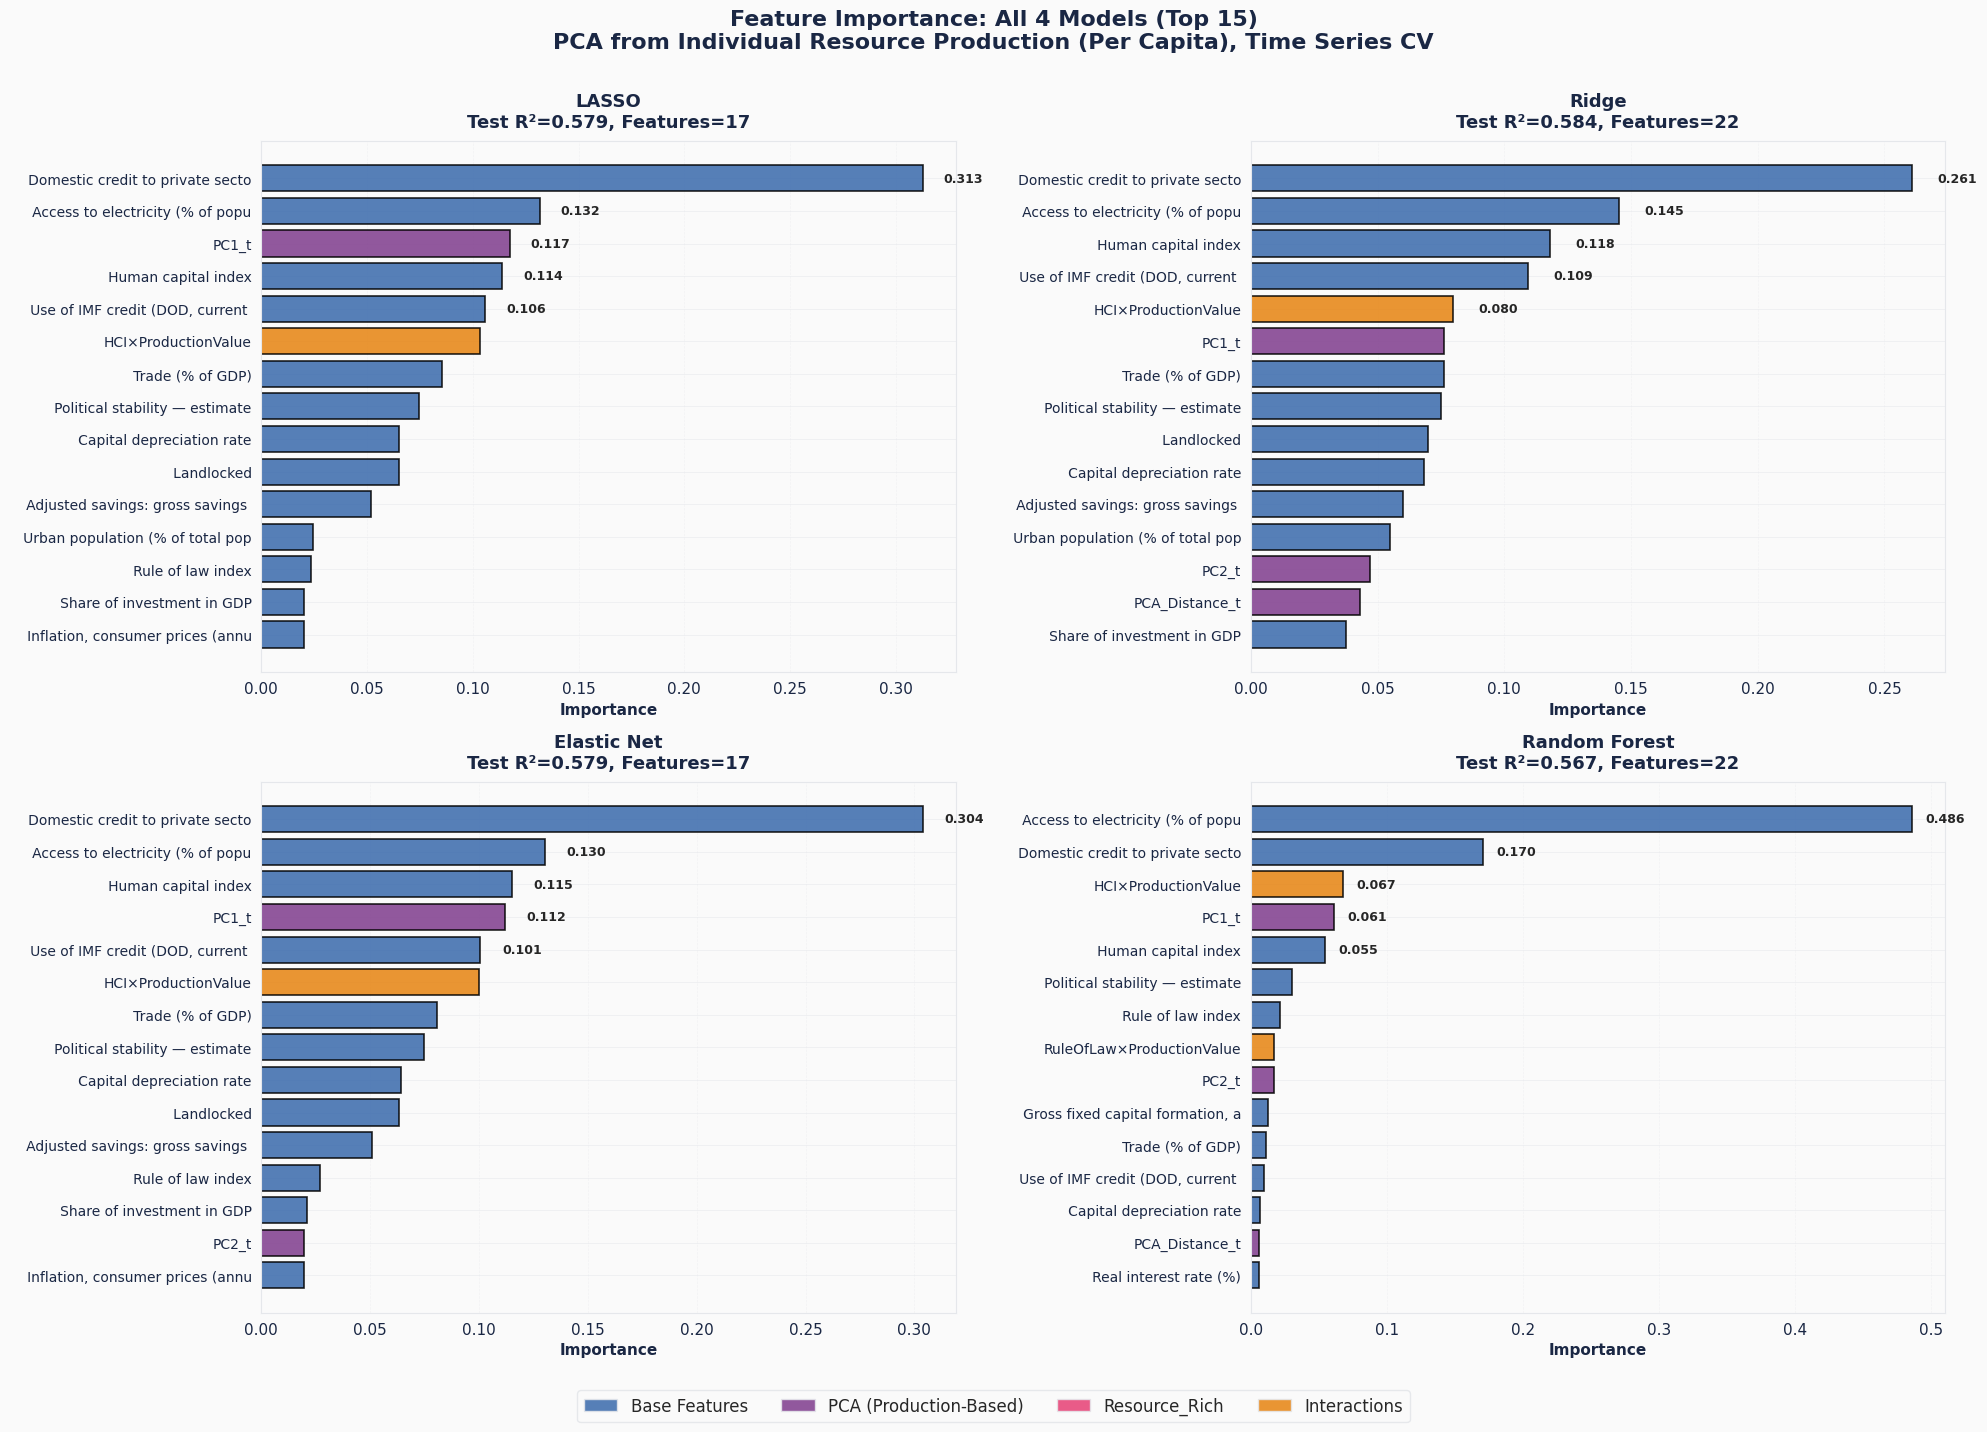


[2/5] Heatmap (top 20 features)...


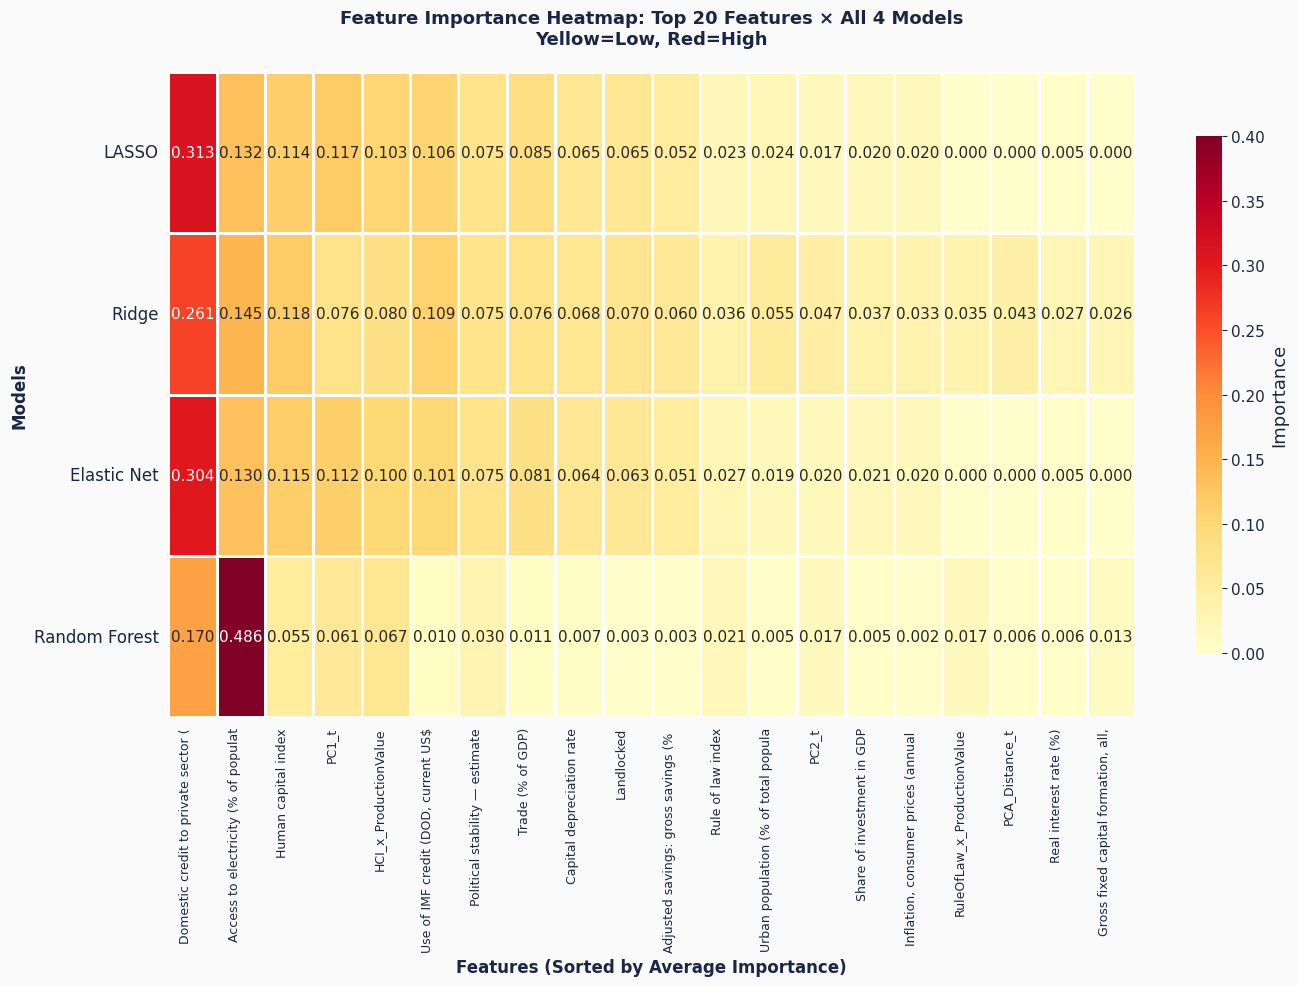


[3/5] Grouped bar chart (top 10)...


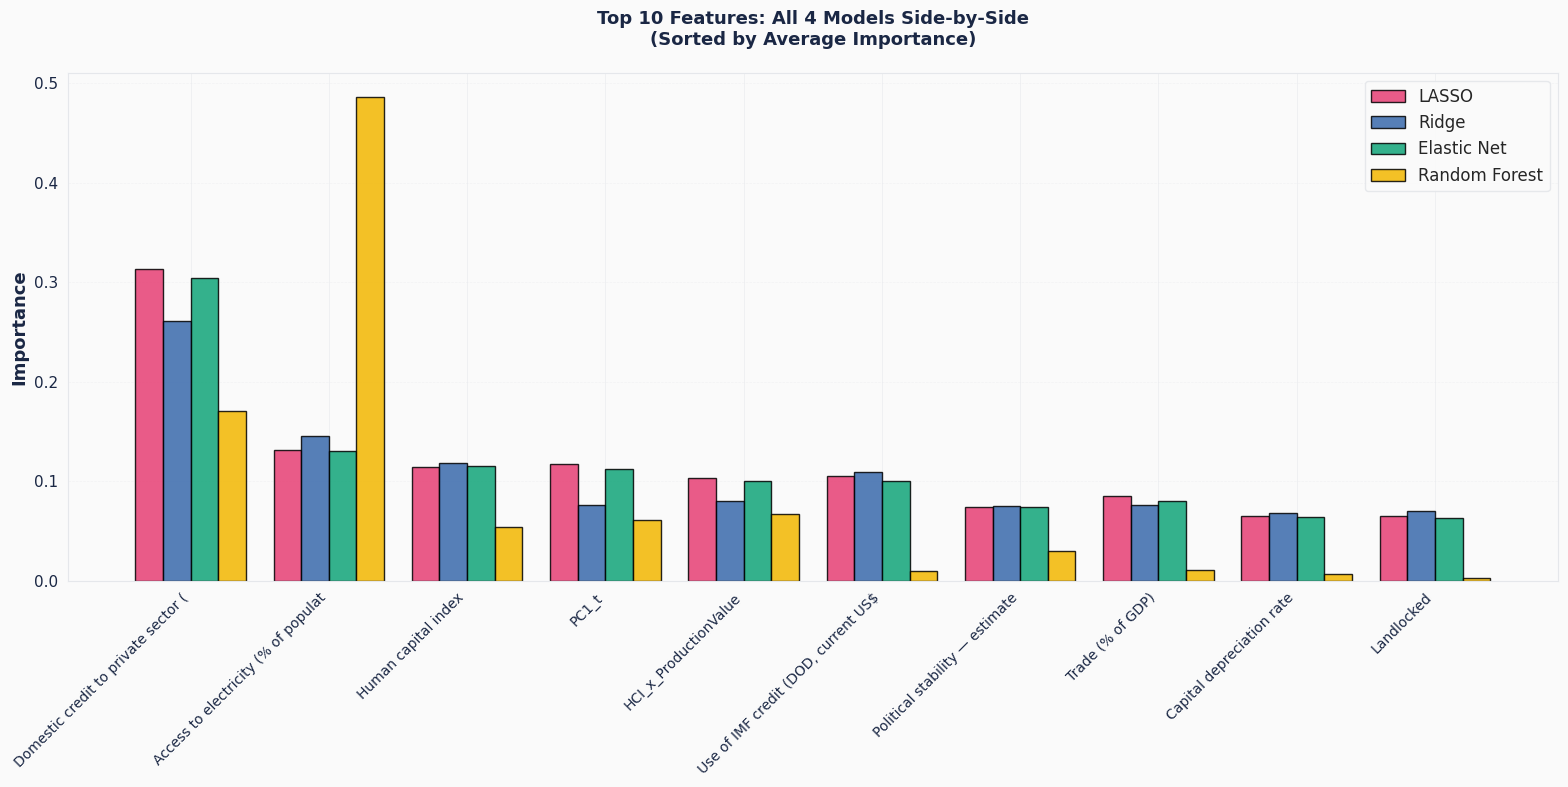


[4/5] Model agreement plot...


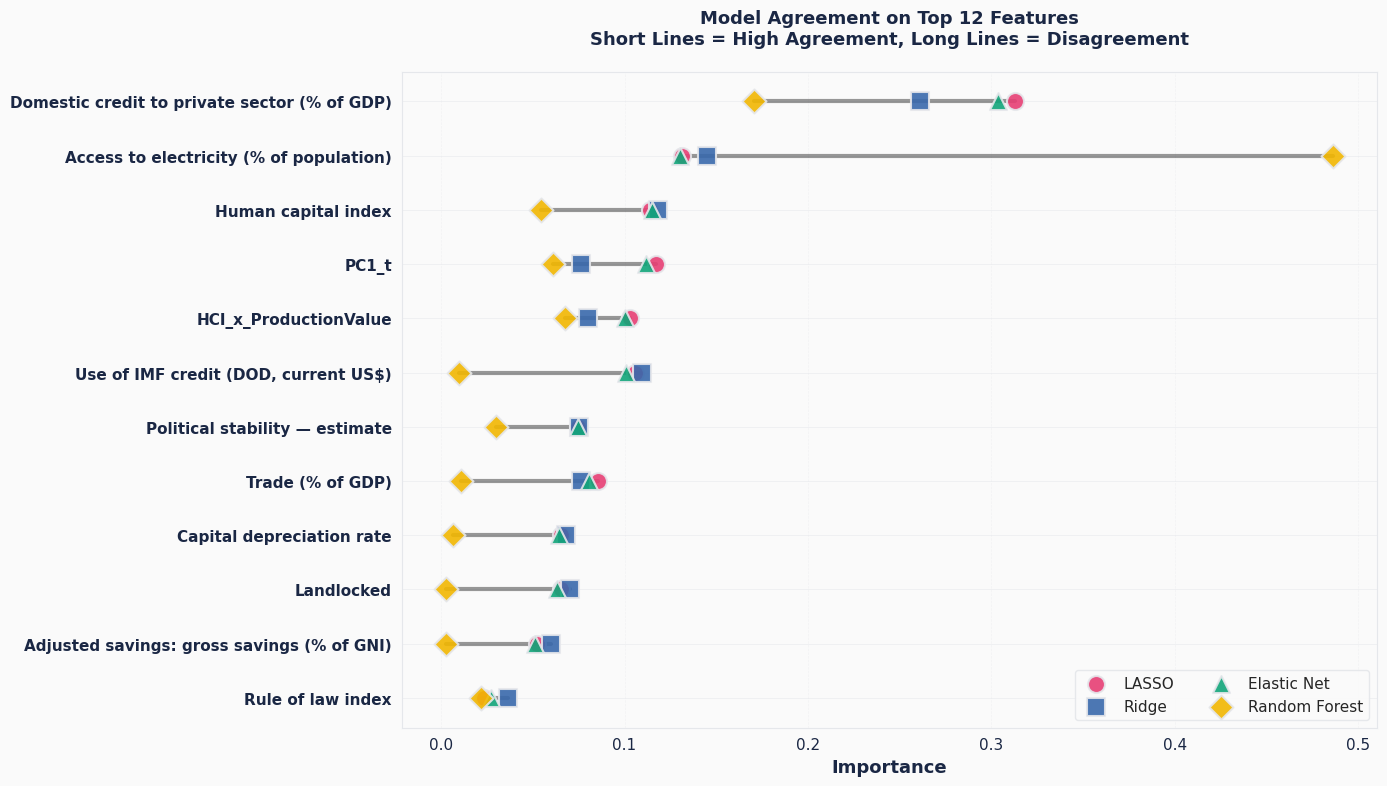


[5/5] PCA transformation trajectory (sample countries)...


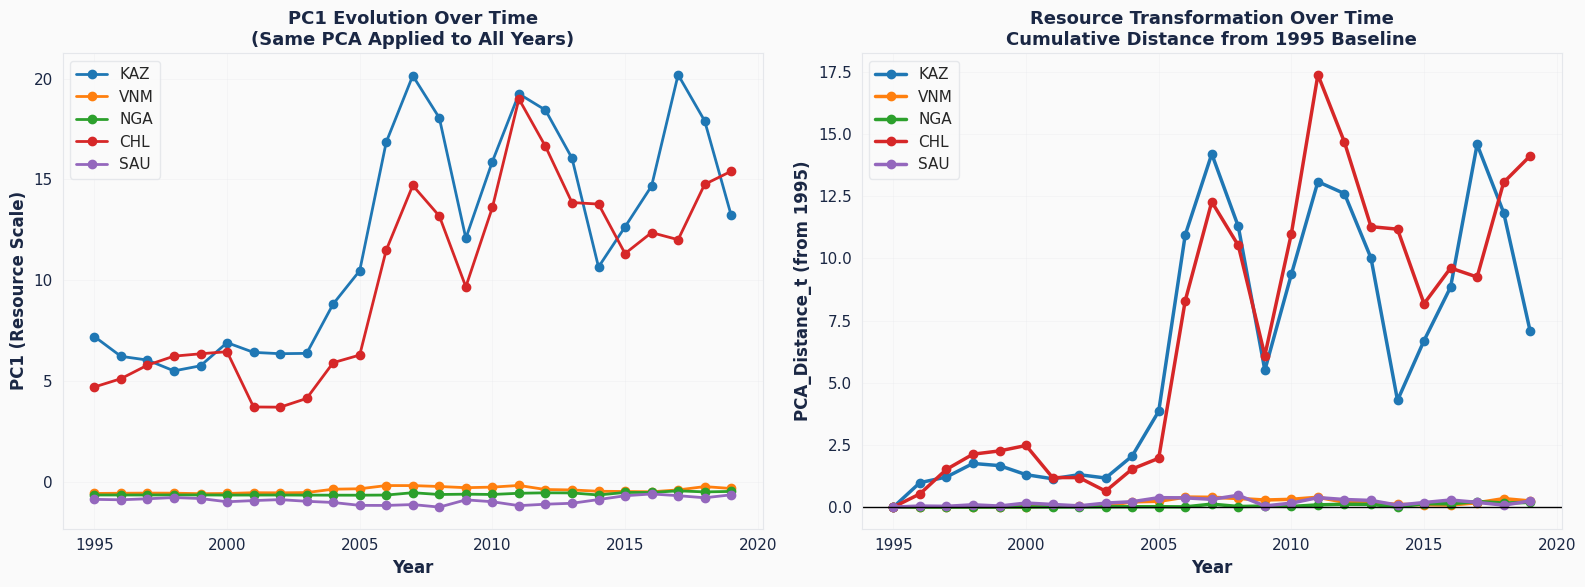


MODEL PERFORMANCE
        Model  Test_R2  Train_R2
        Ridge   0.5843    0.6012
  Elastic Net   0.5795    0.5976
        LASSO   0.5792    0.5992
Random Forest   0.5673    0.7407

TOP 10 CONSENSUS (Average Across All Models):

1. Domestic credit to private sector (% of GDP)
   LASSO: 0.3127, Ridge: 0.2609, Elastic: 0.3038, RF: 0.1705
   Average: 0.2620
   Agreement: High (CV=0.22)

2. Access to electricity (% of population)
   LASSO: 0.1316, Ridge: 0.1452, Elastic: 0.1303, RF: 0.4861
   Average: 0.2233
   Agreement: Low (CV=0.68)

3. Human capital index
   LASSO: 0.1139, Ridge: 0.1180, Elastic: 0.1151, RF: 0.0546
   Average: 0.1004
   Agreement: High (CV=0.26)

4. PC1_t
   LASSO: 0.1174, Ridge: 0.0763, Elastic: 0.1120, RF: 0.0608
   Average: 0.0916
   Agreement: High (CV=0.26)

5. HCI_x_ProductionValue
   LASSO: 0.1032, Ridge: 0.0798, Elastic: 0.1001, RF: 0.0675
   Average: 0.0877
   Agreement: High (CV=0.17)

6. Use of IMF credit (DOD, current US$)
   LASSO: 0.1059, Ridge: 0.1094

In [8]:
# VISUALIZATION 1: 4-Panel Top 15
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
axes = axes.flatten()

for idx, model_name in enumerate(['LASSO', 'Ridge', 'Elastic Net', 'Random Forest']):
    ax = axes[idx]
    
    model_sorted = all_importance.sort_values(model_name, ascending=False).head(15)
    colors = []
    labels = []
    for feat in model_sorted['Feature']:
        if 'PCA' in feat or ('PC' in feat and '_x_' not in feat):
            colors.append(FEAT_COLORS['pca'])
            label_text = f"{feat[:32]}"
        elif '_x_' in feat:
            colors.append(FEAT_COLORS['interaction'])
            label_text = f"{feat.replace('_x_', '×')[:32]}"
        elif 'Resource_Rich' in feat:
            colors.append(FEAT_COLORS['resource'])
            label_text = f"{feat[:32]}"
        else:
            colors.append(FEAT_COLORS['base'])
            label_text = f"   {feat[:32]}"
        labels.append(label_text)
    
    y_pos = np.arange(len(model_sorted))
    bars = ax.barh(y_pos, model_sorted[model_name], color=colors, alpha=0.85, 
                  edgecolor='black', linewidth=1.2)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=10)
    ax.set_xlabel('Importance', fontsize=11, fontweight='bold')
    test_r2 = perf_df[perf_df['Model'] == model_name]['Test_R2'].values[0]
    n_features = len(all_features) if model_name in ['Ridge', 'Random Forest'] else np.sum(all_importance[model_name] != 0)
    ax.set_title(f'{model_name}\nTest R²={test_r2:.3f}, Features={n_features}', 
                fontsize=STYLE['axis_title_size'], fontweight='bold', color=STYLE['title_color'], pad=10)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.4, linestyle='--', color=STYLE['grid_color'])
    
    # Add values for top 5
    for i in range(min(5, len(bars))):
        val = model_sorted[model_name].iloc[i]
        if val > 0.01:
            ax.text(val + 0.01, i, f'{val:.3f}', va='center', fontsize=9, fontweight='bold')


fig.legend(handles=[
    Patch(facecolor=FEAT_COLORS['base'], label='Base Features', alpha=0.85, edgecolor=STYLE['grid_color']),
    Patch(facecolor=FEAT_COLORS['pca'], label='PCA (Production-Based)', alpha=0.85, edgecolor=STYLE['grid_color']),
    Patch(facecolor=FEAT_COLORS['resource'], label='Resource_Rich', alpha=0.85, edgecolor=STYLE['grid_color']),
    Patch(facecolor=FEAT_COLORS['interaction'], label='Interactions', alpha=0.85, edgecolor=STYLE['grid_color'])
], loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=4, fontsize=12, framealpha=0.95)

plt.suptitle('Feature Importance: All 4 Models (Top 15)\nPCA from Individual Resource Production (Per Capita), Time Series CV', 
             fontsize=16, fontweight='bold', color=STYLE['title_color'], y=0.995)
plt.tight_layout(rect=[0, 0.02, 1, 0.99])
plt.show()

# VISUALIZATION 2: Heatmap (Top 20)
print("\n[2/5] Heatmap (top 20 features)...")

fig, ax = plt.subplots(figsize=(14, 10))

top_20 = all_importance.sort_values('Average', ascending=False).head(20)
heatmap_matrix = top_20[['LASSO', 'Ridge', 'Elastic Net', 'Random Forest']].T

sns.heatmap(heatmap_matrix, annot=True, fmt='.3f', cmap='YlOrRd', 
           cbar_kws={'label': 'Importance', 'shrink': 0.8}, 
           linewidths=1, linecolor='white',
           xticklabels=[f[:35] for f in top_20['Feature']],
           yticklabels=['LASSO', 'Ridge', 'Elastic Net', 'Random Forest'],
           ax=ax, vmin=0, vmax=0.4)

ax.set_title('Feature Importance Heatmap: Top 20 Features × All 4 Models\nYellow=Low, Red=High', 
            fontsize=STYLE['axis_title_size'], fontweight='bold', color=STYLE['title_color'], pad=20)
ax.set_xlabel('Features (Sorted by Average Importance)', fontsize=12, fontweight='bold')
ax.set_ylabel('Models', fontsize=12, fontweight='bold')

plt.xticks(rotation=90, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()
plt.show()

# VISUALIZATION 3: Grouped Bar (Top 10)

print("\n[3/5] Grouped bar chart (top 10)...")

fig, ax = plt.subplots(figsize=(16, 8))

top_10 = all_importance.sort_values('Average', ascending=False).head(10)

x = np.arange(len(top_10))
width = 0.2

ax.bar(x - 1.5*width, top_10['LASSO'], width, label='LASSO', 
      alpha=0.85, edgecolor='black', linewidth=1, color=MODEL_COLORS['LASSO'])
ax.bar(x - 0.5*width, top_10['Ridge'], width, label='Ridge', 
      alpha=0.85, edgecolor='black', linewidth=1, color=MODEL_COLORS['Ridge'])
ax.bar(x + 0.5*width, top_10['Elastic Net'], width, label='Elastic Net', 
      alpha=0.85, edgecolor='black', linewidth=1, color=MODEL_COLORS['Elastic Net'])
ax.bar(x + 1.5*width, top_10['Random Forest'], width, label='Random Forest', 
      alpha=0.85, edgecolor='black', linewidth=1, color=MODEL_COLORS['Random Forest'])

ax.set_xticks(x)
ax.set_xticklabels([f[:35] for f in top_10['Feature']], rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Importance', fontsize=STYLE['axis_title_size'], fontweight='bold', color=STYLE['title_color'])
ax.set_title('Top 10 Features: All 4 Models Side-by-Side\n(Sorted by Average Importance)', 
            fontsize=STYLE['axis_title_size'], fontweight='bold', color=STYLE['title_color'], pad=20)
ax.legend(fontsize=12, loc='upper right', framealpha=0.95)
ax.grid(axis='y', alpha=0.4, linestyle='--', color=STYLE['grid_color'])

plt.tight_layout()
plt.show()

# VISUALIZATION 4: Model Agreement with Ranges
print("\n[4/5] Model agreement plot...")

fig, ax = plt.subplots(figsize=(14, 8))
top_12 = all_importance.sort_values('Average', ascending=False).head(12)

# For each feature, plot model values and range
y_pos = np.arange(len(top_12))

for i, (_, row) in enumerate(top_12.iterrows()):
    vals = [row['LASSO'], row['Ridge'], row['Elastic Net'], row['Random Forest']]
    
    # Plot range line
    ax.plot([min(vals), max(vals)], [i, i], 'k-', alpha=0.4, linewidth=3, zorder=1)
    
    # Plot model points
    ax.scatter(row['LASSO'], i, marker='o', s=150, alpha=0.9, 
              color=MODEL_COLORS['LASSO'], edgecolor=STYLE['grid_color'], linewidth=1.5, zorder=3, label='LASSO' if i==0 else '')
    ax.scatter(row['Ridge'], i, marker='s', s=150, alpha=0.9, 
              color=MODEL_COLORS['Ridge'], edgecolor=STYLE['grid_color'], linewidth=1.5, zorder=3, label='Ridge' if i==0 else '')
    ax.scatter(row['Elastic Net'], i, marker='^', s=150, alpha=0.9, 
              color=MODEL_COLORS['Elastic Net'], edgecolor=STYLE['grid_color'], linewidth=1.5, zorder=3, label='Elastic Net' if i==0 else '')
    ax.scatter(row['Random Forest'], i, marker='D', s=150, alpha=0.9, 
              color=MODEL_COLORS['Random Forest'], edgecolor=STYLE['grid_color'], linewidth=1.5, zorder=3, label='Random Forest' if i==0 else '')

ax.set_yticks(y_pos)
ax.set_yticklabels([f[:45] for f in top_12['Feature']], fontsize=11, fontweight='bold')
ax.set_xlabel('Importance', fontsize=STYLE['axis_title_size'], fontweight='bold', color=STYLE['title_color'])
ax.set_title('Model Agreement on Top 12 Features\nShort Lines = High Agreement, Long Lines = Disagreement', 
            fontsize=STYLE['axis_title_size'], fontweight='bold', color=STYLE['title_color'], pad=20)
ax.invert_yaxis()
ax.legend(fontsize=11, loc='lower right', framealpha=0.95, ncol=2)
ax.grid(axis='x', alpha=0.4, linestyle='--', color=STYLE['grid_color'])

plt.tight_layout()
plt.show()

# VISUALIZATION 5: PCA Trajectory Example
print("\n[5/5] PCA transformation trajectory (sample countries)...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sample countries
sample_countries = ['KAZ', 'VNM', 'NGA', 'CHL', 'SAU']
sample_data = df[df['Country Code'].isin(sample_countries)]

# PC1 over time
ax = axes[0]
for country in sample_countries:
    country_data = sample_data[sample_data['Country Code'] == country]
    ax.plot(country_data['Year'], country_data['PC1_t'], marker='o', label=country, linewidth=2)

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('PC1 (Resource Scale)', fontsize=12, fontweight='bold')
ax.set_title('PC1 Evolution Over Time\n(Same PCA Applied to All Years)', fontsize=STYLE['axis_title_size'], fontweight='bold', color=STYLE['title_color'])
ax.legend()
ax.grid(alpha=0.4, color=STYLE['grid_color'])

# PCA_Distance over time
ax = axes[1]
for country in sample_countries:
    country_data = sample_data[sample_data['Country Code'] == country]
    ax.plot(country_data['Year'], country_data['PCA_Distance_t'], marker='o', label=country, linewidth=2.5)

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('PCA_Distance_t (from 1995)', fontsize=12, fontweight='bold')
ax.set_title('Resource Transformation Over Time\nCumulative Distance from 1995 Baseline', 
             fontsize=STYLE['axis_title_size'], fontweight='bold', color=STYLE['title_color'])
ax.legend()
ax.grid(alpha=0.4, color=STYLE['grid_color'])
ax.axhline(0, color='black', linestyle='-', linewidth=1)

plt.tight_layout()
plt.show()

# SUMMARY STATISTICS

print("\n" + "="*80)
print("MODEL PERFORMANCE")
print("="*80)
print(perf_df.to_string(index=False, float_format='%.4f'))

print("\n" + "="*80)
print("TOP 10 CONSENSUS (Average Across All Models):")
print("="*80)

for i, (_, row) in enumerate(top_10.iterrows(), 1):
    print(f"\n{i}. {row['Feature']}")
    print(f"   LASSO: {row['LASSO']:.4f}, Ridge: {row['Ridge']:.4f}, "
          f"Elastic: {row['Elastic Net']:.4f}, RF: {row['Random Forest']:.4f}")
    print(f"   Average: {row['Average']:.4f}")
    
    # Calculate coefficient of variation (measure of agreement)
    vals = [row['LASSO'], row['Ridge'], row['Elastic Net'], row['Random Forest']]
    cv = np.std(vals) / np.mean(vals) if np.mean(vals) > 0 else 0
    agreement = "High" if cv < 0.3 else "Medium" if cv < 0.6 else "Low"
    print(f"   Agreement: {agreement} (CV={cv:.2f})")

print("\n" + "="*80)
print("PCA COMPONENTS (All Models):")
print("="*80)

for feat in ['PC1_t', 'PC2_t', 'PCA_Distance_t']:
    row = all_importance[all_importance['Feature'] == feat].iloc[0]
    rank = all_importance.sort_values('Average', ascending=False)[
        all_importance.sort_values('Average', ascending=False)['Feature'] == feat
    ].index[0] + 1
    
    print(f"\n{feat}:")
    print(f"   LASSO: {row['LASSO']:.4f}, Ridge: {row['Ridge']:.4f}, "
          f"Elastic: {row['Elastic Net']:.4f}, RF: {row['Random Forest']:.4f}")
    print(f"   Average: {row['Average']:.4f} (Rank #{rank}/{len(all_features)})")
